In [1]:
!pip install lightgbm

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import warnings
warnings.filterwarnings('ignore')

In [12]:
train = pd.read_csv(r"C:\Users\hp220\OneDrive\Desktop\customer_churn\data\train.csv")
test = pd.read_csv(r"C:\Users\hp220\OneDrive\Desktop\customer_churn\data\test.csv")

print(train.shape)
print(test.shape)

train.head()

(243787, 21)
(104480, 20)


,AccountAge,MonthlyCharges,TotalCharges,SubscriptionType,PaymentMethod,PaperlessBilling,ContentType,MultiDeviceAccess,DeviceRegistered,ViewingHoursPerWeek,...,ContentDownloadsPerMonth,GenrePreference,UserRating,SupportTicketsPerMonth,Gender,WatchlistSize,ParentalControl,SubtitlesEnabled,CustomerID,Churn
0,20,11.055215,221.104302,Premium,Mailed check,No,Both,No,Mobile,36.758104,...,10,Sci-Fi,2.176498,4,Male,3,No,No,CB6SXPNVZA,0
1,57,5.175208,294.986882,Basic,Credit card,Yes,Movies,No,Tablet,32.450568,...,18,Action,3.478632,8,Male,23,No,Yes,S7R2G87O09,0
2,73,12.106657,883.785952,Basic,Mailed check,Yes,Movies,No,Computer,7.395160,...,23,Fantasy,4.238824,6,Male,1,Yes,Yes,EASDC20BDT,0
3,32,7.263743,232.439774,Basic,Electronic check,No,TV Shows,No,Tablet,27.960389,...,30,Drama,4.276013,2,Male,24,Yes,Yes,NPF69NT69N,0
4,57,16.953078,966.325422,Premium,Electronic check,Yes,TV Shows,No,TV,20.083397,...,20,Comedy,3.616170,4,Female,0,No,No,4LGYPK7VOL,0


In [13]:
train.drop("CustomerID", axis=1, inplace=True)
test.drop("CustomerID", axis=1, inplace=True)

train.isnull().sum()

AccountAge                  0
MonthlyCharges              0
TotalCharges                0
SubscriptionType            0
PaymentMethod               0
PaperlessBilling            0
ContentType                 0
MultiDeviceAccess           0
DeviceRegistered            0
ViewingHoursPerWeek         0
AverageViewingDuration      0
ContentDownloadsPerMonth    0
GenrePreference             0
UserRating                  0
SupportTicketsPerMonth      0
Gender                      0
WatchlistSize               0
ParentalControl             0
SubtitlesEnabled            0
Churn                       0
dtype: int64

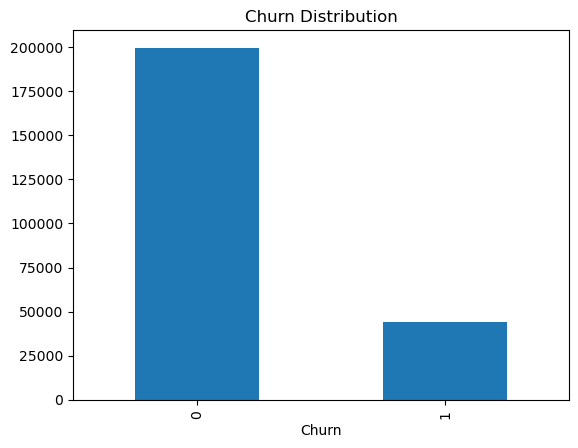

In [7]:
train["Churn"].value_counts().plot(kind="bar")
plt.title("Churn Distribution")
plt.show()

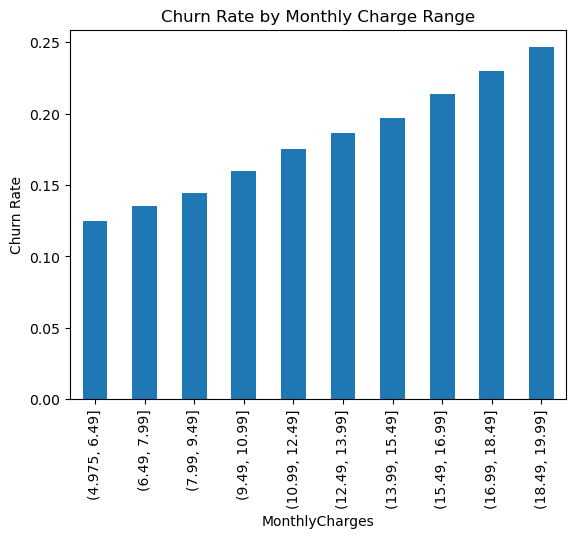

In [14]:
train.groupby(pd.cut(train["MonthlyCharges"], bins=10))["Churn"].mean().plot(kind="bar")
plt.title("Churn Rate by Monthly Charge Range")
plt.ylabel("Churn Rate")
plt.show()

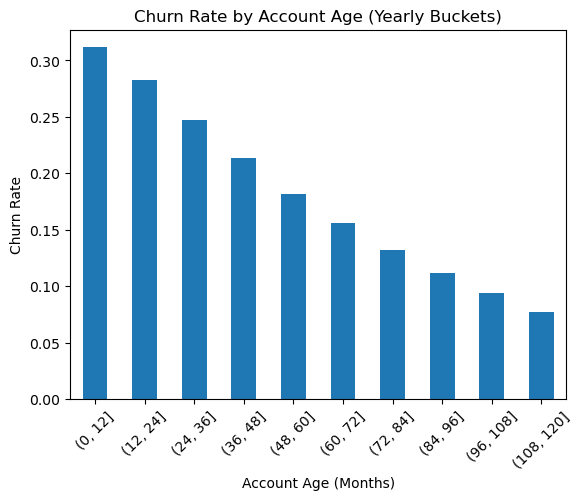

In [15]:
import numpy as np

bins = np.arange(0, 121, 12)  # 0,12,24,...120

train.groupby(pd.cut(train["AccountAge"], bins=bins))["Churn"].mean().plot(kind="bar")

plt.title("Churn Rate by Account Age (Yearly Buckets)")
plt.xlabel("Account Age (Months)")
plt.ylabel("Churn Rate")
plt.xticks(rotation=45)
plt.show()

In [16]:
train["ComplaintRate"] = train["SupportTicketsPerMonth"] / (train["AccountAge"] + 1)

train["RevenuePerMonth"] = train["TotalCharges"] / (train["AccountAge"] + 1)

train["CLV"] = train["MonthlyCharges"] * train["AccountAge"]

train["EngagementRatio"] = train["ViewingHoursPerWeek"] / (train["AccountAge"] + 1)

train["DownloadIntensity"] = train["ContentDownloadsPerMonth"] / (train["ViewingHoursPerWeek"] + 1)

train["SupportBurden"] = train["SupportTicketsPerMonth"] / (train["ViewingHoursPerWeek"] + 1)

train["WatchlistUtilization"] = train["WatchlistSize"] / (train["ViewingHoursPerWeek"] + 1)

train["RevenuePerViewingHour"] = train["TotalCharges"] / (
    train["ViewingHoursPerWeek"] * train["AccountAge"] + 1
)

In [17]:
X = train.drop("Churn", axis=1)
y = train["Churn"]

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [18]:
categorical_cols = X_train.select_dtypes(include="object").columns

X_train = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_val = pd.get_dummies(X_val, columns=categorical_cols, drop_first=True)

X_train, X_val = X_train.align(X_val, join="left", axis=1, fill_value=0)

In [19]:
numerical_cols = X_train.select_dtypes(include=["int64", "float64"]).columns

scaler = StandardScaler()

X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_val[numerical_cols] = scaler.transform(X_val[numerical_cols])

In [20]:
model_lr = LogisticRegression(max_iter=5000, class_weight="balanced")
scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])

model_rf = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42
)

model_xgb = XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss"
)

In [21]:
results = {}

for name, model in {
    "Logistic": model_lr,
    "RandomForest": model_rf,
    "XGBoost": model_xgb
}.items():

    model.fit(X_train, y_train)
    pred = model.predict_proba(X_val)[:,1]

    results[name] = roc_auc_score(y_val, pred)

pd.DataFrame(results, index=["AUC"]).T

,AUC
Logistic,0.754398
RandomForest,0.736926
XGBoost,0.748598


In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier

scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])

param_grid = {
    "max_depth": [4,5,6,7,8],
    "learning_rate": [0.01,0.03,0.05,0.1],
    "n_estimators": [300,400,500,700],
    "subsample": [0.7,0.8,0.9],
    "colsample_bytree": [0.7,0.8,0.9],
    "min_child_weight": [1,3,5],
    "gamma": [0,0.1,0.3]
}

xgb = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

search = RandomizedSearchCV(
    xgb,
    param_grid,
    n_iter=25,
    scoring="roc_auc",
    cv=3,
    verbose=1,
    n_jobs=-1
)

search.fit(X_train, y_train)

print("Best Parameters:", search.best_params_)
print("Best CV AUC:", search.best_score_)

In [22]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score

final_xgb = XGBClassifier(
    subsample=0.8,
    n_estimators=500,
    min_child_weight=5,
    max_depth=6,
    learning_rate=0.01,
    gamma=0,
    colsample_bytree=0.9,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

final_xgb.fit(X_train, y_train)

y_prob_final = final_xgb.predict_proba(X_val)[:,1]

print("Final XGBoost AUC:", roc_auc_score(y_val, y_prob_final))

Final XGBoost AUC: 0.7513753618925272


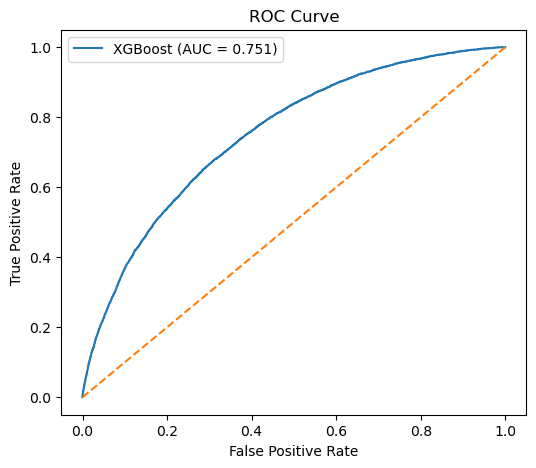

In [23]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_val, y_prob_final)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label="XGBoost (AUC = %.3f)" % roc_auc_score(y_val, y_prob_final))
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()

In [24]:
from sklearn.metrics import f1_score
import numpy as np

thresholds = np.arange(0.1,0.9,0.01)

best_t = 0.5
best_f1 = 0

for t in thresholds:
    
    preds = (y_prob_final > t).astype(int)
    
    f1 = f1_score(y_val, preds)

    if f1 > best_f1:
        best_f1 = f1
        best_t = t

print("Best Threshold:", best_t)
print("Best F1 Score:", best_f1)

Best Threshold: 0.5499999999999998
Best F1 Score: 0.4437997957099081


In [25]:
from sklearn.metrics import confusion_matrix

preds = (y_prob_final > best_t).astype(int)

cm = confusion_matrix(y_val, preds)

print(cm)

[[29714 10207]
 [ 3406  5431]]


In [26]:
from sklearn.metrics import classification_report

print(classification_report(y_val, preds))

              precision    recall  f1-score   support

           0       0.90      0.74      0.81     39921
           1       0.35      0.61      0.44      8837

    accuracy                           0.72     48758
   macro avg       0.62      0.68      0.63     48758
weighted avg       0.80      0.72      0.75     48758



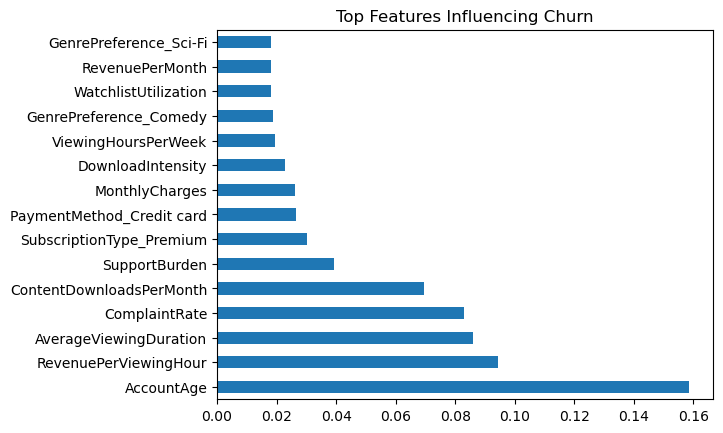

In [27]:
# features driving churn overall.
importance = pd.Series(final_xgb.feature_importances_, index=X_train.columns)

importance.sort_values(ascending=False).head(15).plot(kind="barh")

plt.title("Top Features Influencing Churn")
plt.show()

In [28]:
from lightgbm import LGBMClassifier

model_lgb = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model_lgb.fit(X_train, y_train)

y_prob_lgb = model_lgb.predict_proba(X_val)[:,1]

print("LightGBM AUC:", roc_auc_score(y_val, y_prob_lgb))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 35345, number of negative: 159684
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.020493 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3561
[LightGBM] [Info] Number of data points in the train set: 195029, number of used features: 36
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.181229 -> initscore=-1.508040
[LightGBM] [Info] Start training from score -1.508040
LightGBM AUC: 0.7497896440978458


In [29]:
from sklearn.ensemble import AdaBoostClassifier

model_ab = AdaBoostClassifier(
    n_estimators=300,
    learning_rate=0.05,
    random_state=42
)

model_ab.fit(X_train, y_train)

y_prob_ab = model_ab.predict_proba(X_val)[:,1]

print("AdaBoost AUC:", roc_auc_score(y_val, y_prob_ab))

AdaBoost AUC: 0.7474543597374192


In [30]:
y_prob_lr = model_lr.predict_proba(X_val)[:,1]
y_prob_rf = model_rf.predict_proba(X_val)[:,1]
y_prob_xgb = model_xgb.predict_proba(X_val)[:,1]

In [32]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost", "LightGBM", "AdaBoost"],
    "AUC": [
        roc_auc_score(y_val, y_prob_lr),
        roc_auc_score(y_val, y_prob_rf),
        roc_auc_score(y_val, y_prob_final),
        roc_auc_score(y_val, y_prob_lgb),
        roc_auc_score(y_val, y_prob_ab)
    ]
})

comparison = comparison.sort_values("AUC", ascending=False)

comparison

,Model,AUC
0,Logistic Regression,0.754398
2,XGBoost,0.751375
3,LightGBM,0.749790
4,AdaBoost,0.747454
1,Random Forest,0.736926


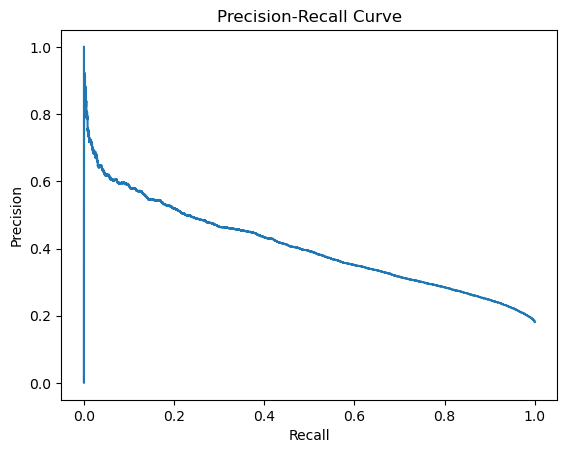

In [33]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_val, y_prob_final)

plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.show()

TESTING

In [35]:
test = pd.read_csv(r"C:\Users\hp220\OneDrive\Desktop\customer_churn\data\test.csv")
test_ids = test["CustomerID"]
test = test.drop("CustomerID", axis=1)

In [36]:
test["ComplaintRate"] = test["SupportTicketsPerMonth"] / (test["AccountAge"] + 1)

test["RevenuePerMonth"] = test["TotalCharges"] / (test["AccountAge"] + 1)

test["CLV"] = test["MonthlyCharges"] * test["AccountAge"]

test["EngagementRatio"] = test["ViewingHoursPerWeek"] / (test["AccountAge"] + 1)

test["DownloadIntensity"] = test["ContentDownloadsPerMonth"] / (test["ViewingHoursPerWeek"] + 1)

test["SupportBurden"] = test["SupportTicketsPerMonth"] / (test["ViewingHoursPerWeek"] + 1)

test["WatchlistUtilization"] = test["WatchlistSize"] / (test["ViewingHoursPerWeek"] + 1)

test["RevenuePerViewingHour"] = test["TotalCharges"] / (
    test["ViewingHoursPerWeek"] * test["AccountAge"] + 1
)

In [37]:
test = pd.get_dummies(test, columns=categorical_cols, drop_first=True)

In [38]:
X_train, test = X_train.align(test, join="left", axis=1, fill_value=0)

In [39]:
test[numerical_cols] = scaler.transform(test[numerical_cols])

In [40]:
test_prob = final_xgb.predict_proba(test)[:,1]

np.min(test_prob), np.max(test_prob)

(0.032671347, 0.92121744)

Threshold Optimization

Since churn prediction is an imbalanced classification problem, using the default threshold of 0.5 may lead to very conservative predictions. Therefore, multiple thresholds were tested to balance precision and recall. A threshold of approximately 0.28 produced the most reasonable distribution of predicted churners while maintaining strong model performance.

In [41]:
threshold = 0.28
test_pred = (test_prob > threshold).astype(int)

In [42]:
submission = pd.DataFrame({
    "CustomerID": test_ids,
    "ChurnProbability": test_prob,
    "ChurnPrediction": test_pred
})

In [43]:
submission.to_csv("churn_predictions.csv", index=False)

Test Dataset Predictions

The final model identified 6.35% of customers in the test dataset as high churn risk using an optimized classification threshold. Since the model prioritizes high-confidence churn predictions, the predicted churn rate is lower than the training dataset distribution. This conservative approach helps businesses focus retention efforts on the most at-risk customers.

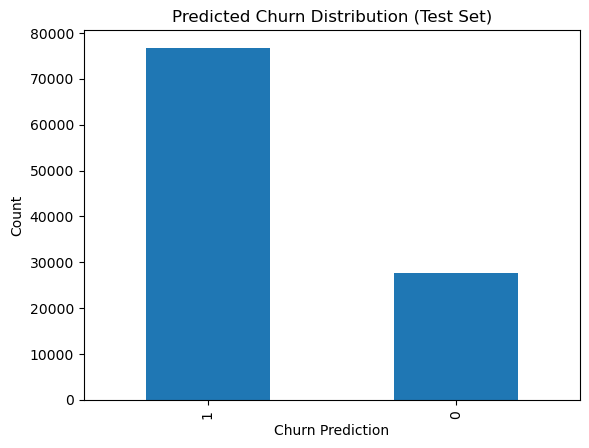

In [45]:
# Final Prediction Distribution

submission["ChurnPrediction"].value_counts().plot(kind="bar")

plt.title("Predicted Churn Distribution (Test Set)")
plt.xlabel("Churn Prediction")
plt.ylabel("Count")

plt.show()

In [46]:
submission.sort_values("ChurnProbability", ascending=False).head(10)

,CustomerID,ChurnProbability,ChurnPrediction
69817,YOH99XQQXF,0.921217,1
49193,L5CHGPO1XA,0.918758,1
53026,AMUS79L7TP,0.918605,1
18647,9IURSYDCXJ,0.918334,1
101539,9HEVLXYK3Z,0.917826,1
10132,BZYBMV88JS,0.917529,1
23847,5MVUABYTZ1,0.916735,1
27779,WP1UJ8REW8,0.915752,1
75085,K27W9NUPUZ,0.915477,1
5764,0051AB61SD,0.915463,1


Customer risk segmentation:

In [47]:
submission["RiskLevel"] = pd.cut(
    submission["ChurnProbability"],
    bins=[0,0.2,0.4,1],
    labels=["Low Risk","Medium Risk","High Risk"]
)

submission["RiskLevel"].value_counts()

RiskLevel
High Risk      56946
Medium Risk    32382
Low Risk       15152
Name: count, dtype: int64

SHAP explanability

In [49]:
import numpy
print(numpy.__version__)

1.26.4


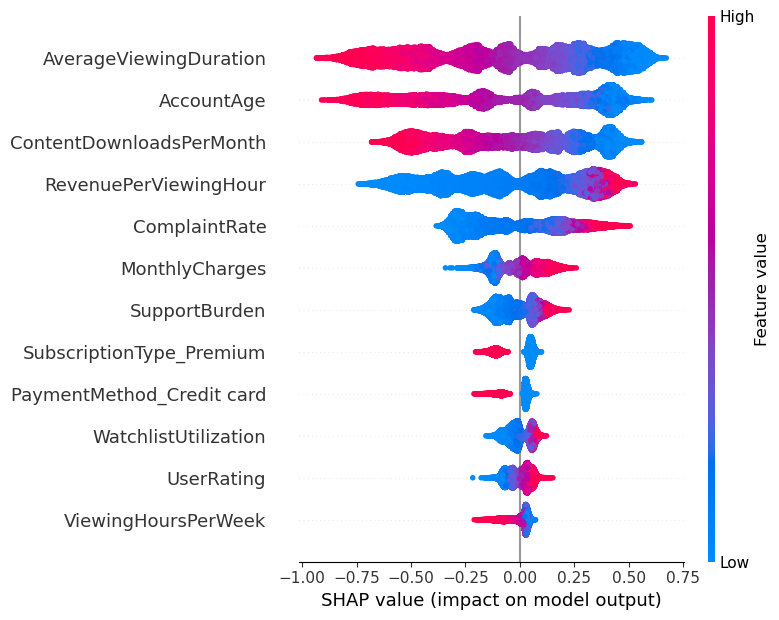

<Figure size 640x480 with 0 Axes>

In [48]:
import shap
import matplotlib.pyplot as plt

explainer = shap.TreeExplainer(final_xgb)
shap_values = explainer.shap_values(X_val)

plt.figure(figsize=(8,4))  # width, height
shap.summary_plot(shap_values, X_val, max_display=12)
plt.tight_layout()
plt.show()

In [51]:
validation_df = pd.DataFrame({
    "ChurnProbability": y_prob_final,
    "Churn": y_val
})

validation_df.to_csv("output/validation_predictions.csv", index=False)